# **Phase 5: Visualizations**

## Phase 5: Data Visualization & Insights
In this final phase, we transform our RFM segments into visual intelligence. We will analyze the volume of each customer group and investigate the distribution of Recency, Frequency, and Monetary metrics across different segments.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("rfm_segmented_output.csv")
df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,326,1,77183.60,1,1,5,115,At Risk / Lost Customers
1,2,7,4310.00,5,5,5,555,Champions
2,75,4,1797.24,2,4,4,244,Loyal Customers
3,19,1,1757.55,4,1,4,414,About to Sleep
4,310,1,334.40,1,1,2,112,At Risk / Lost Customers


### Step 5.1: Customer Segment Distribution (Bar Chart)
We will use a Matplotlib bar chart to analyze the absolute volume of customers mapped to each business segment.

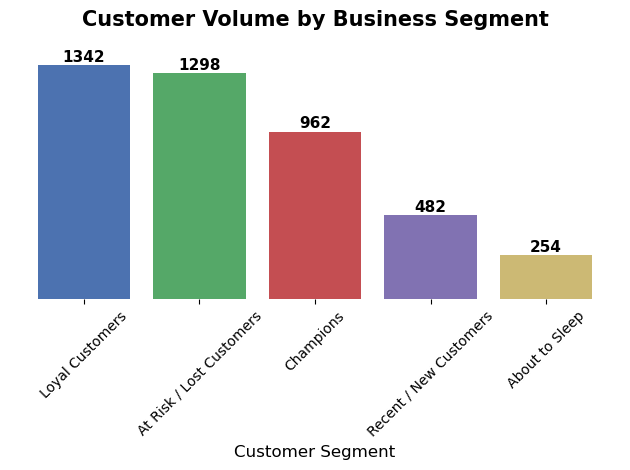

In [8]:
# Prepare the distribution data
segment_counts = df['Segment'].value_counts()
segments = segment_counts.index
counts = segment_counts.values

# Generate the vertical bar chart
plt.bar(segments, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])

# Add structural titles and X-axis label
plt.title('Customer Volume by Business Segment', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=12)

# Professional Cleanup: Removing Y-axis and Spines (Borders)
plt.gca().get_yaxis().set_visible(False) # Hides Y-axis numbers and label
for spine in plt.gca().spines.values():
    spine.set_visible(False) # Removes the box/border around the chart

plt.xticks(rotation=45)

# Dynamic loop to overlay data labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### Step 5.2: Segment Proportions via Treemap Matrix
Since the scatter plot caused visual overlapping where smaller or low-frequency groups like 'Recent Customers' were hidden, we implement a structural Treemap. This grid layout ensures every business segment receives a distinct, non-overlapping boundary proportional to its volume.

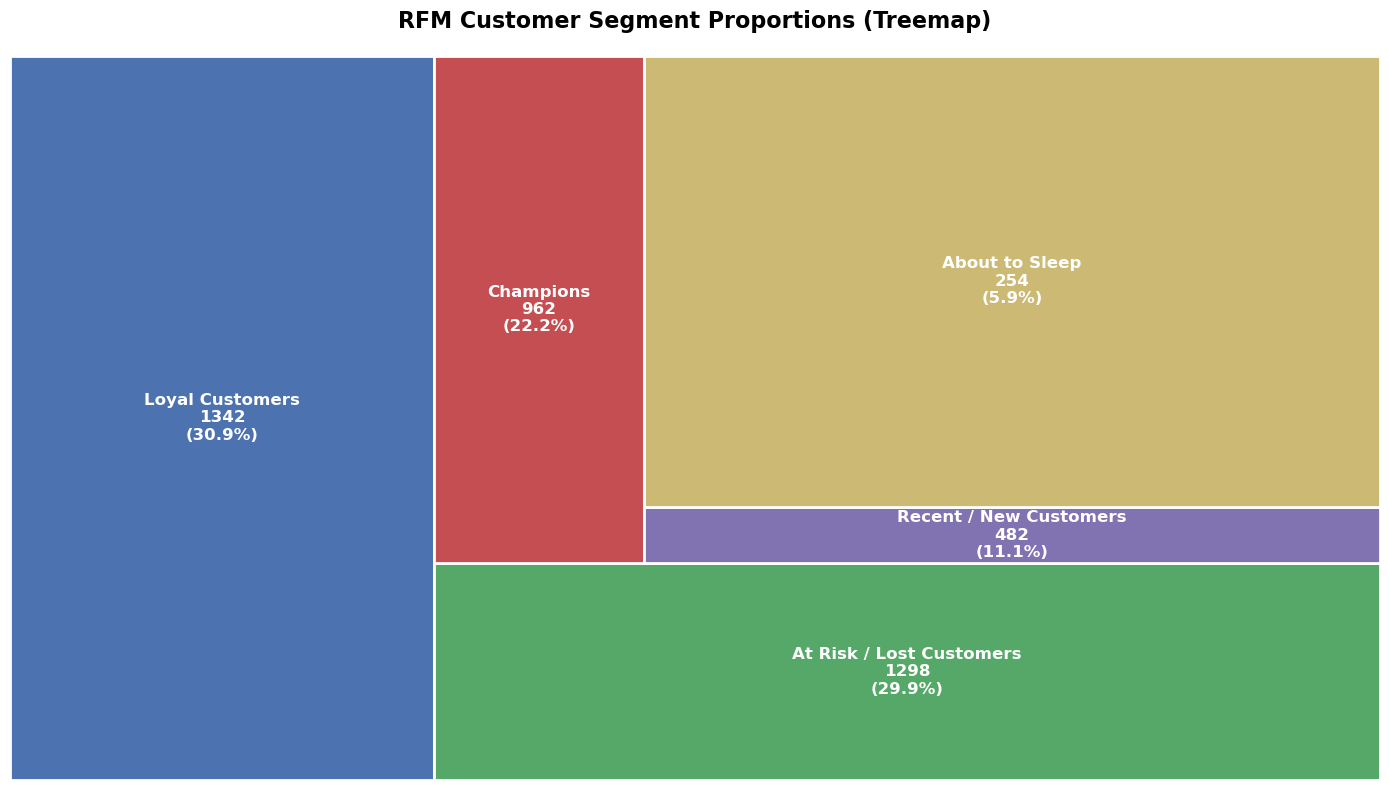

In [9]:
# Prepare and sort the distribution data
segment_counts = df['Segment'].value_counts()
labels = segment_counts.index
values = segment_counts.values
total = sum(values)

# Define clean professional colors matching our bar chart theme
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

# Initialize a grid plot for custom block tiling
fig, ax = plt.subplots(figsize=(14, 8))

# Define initial coordinates for structural packing
x, y = 0.0, 0.0
width, height = 100.0, 100.0

# Calculate layout proportions and draw explicit behavioral blocks
for i in range(len(values)):
    perc = values[i] / total
    
    # Alternate layout splitting to create a clean grid structure
    if i % 2 == 0:
        w_block = width * perc if i < len(values)-1 else width
        h_block = height
        rect = plt.Rectangle((x, y), w_block, h_block, facecolor=colors[i], edgecolor='white', linewidth=2)
        
        # Add text labels inside the block
        ax.text(x + w_block/2, y + h_block/2, f"{labels[i]}\n{values[i]}\n({perc*100:.1f}%)", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)
        x += w_block
        width -= w_block
    else:
        w_block = width
        h_block = height * perc if i < len(values)-1 else height
        rect = plt.Rectangle((x, y), w_block, h_block, facecolor=colors[i], edgecolor='white', linewidth=2)
        
        # Add text labels inside the block
        ax.text(x + w_block/2, y + h_block/2, f"{labels[i]}\n{values[i]}\n({perc*100:.1f}%)", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)
        y += h_block
        height -= h_block
        
    ax.add_patch(rect)

# Format axes to fully isolate the Treemap container
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.axis('off')

plt.title('RFM Customer Segment Proportions (Treemap)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Step 5.3: Revenue Share by Segment (Pie Chart)
This visualization displays the structural proportion of lifetime monetary revenue contributed by each distinct behavioral customer category.

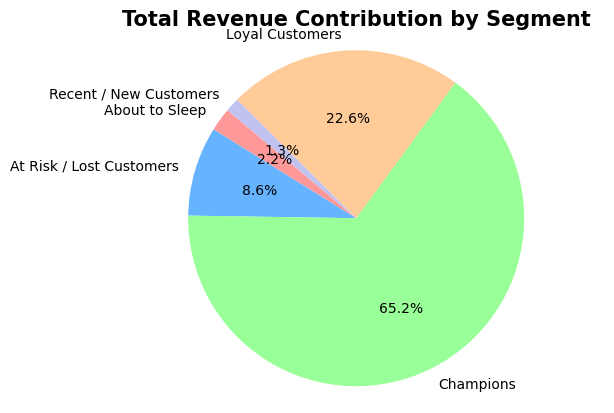

In [5]:
# Aggregate total monetary value grouped by customer segment
revenue_dist = df.groupby('Segment')['Monetary'].sum()

# Generate the structural pie chart
plt.pie(revenue_dist, labels=revenue_dist.index, autopct='%1.1f%%', 
        startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])

plt.title('Total Revenue Contribution by Segment', fontsize=15, fontweight='bold')
plt.axis('equal') # Forces the chart layout to maintain a perfect circle
plt.show()

### Step 5.4: Segment Performance Summary Matrix
We conclude by evaluating the mathematical mean of Recency, Frequency, and Monetary attributes to profile the average behavior of each group.

In [6]:
# Compute descriptive averages across target metrics
summary = df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print("--- Segment Wise Average Metrics ---")
print(summary)

--- Segment Wise Average Metrics ---
                          Recency  Frequency  Monetary
Segment                                               
About to Sleep              34.94       1.70    788.66
At Risk / Lost Customers   218.66       1.43    591.71
Champions                   12.86      11.08   6038.82
Loyal Customers             58.66       3.77   1500.92
Recent / New Customers      36.58       1.09    247.88
